Shapes: train (96, 4) val (24, 4) test (30, 4)
GA gen 1/8
  indiv 0: hidden 14 lr 0.46554 mom 0.6499  val_loss 0.0000
  indiv 1: hidden 17 lr 0.44178 mom 0.4373  val_loss 0.0001
  indiv 2: hidden 17 lr 0.68300 mom 0.3809  val_loss 0.0002
  indiv 3: hidden 14 lr 0.38624 mom 0.3818  val_loss 0.0001
  indiv 4: hidden 13 lr 0.12870 mom 0.1497  val_loss 0.0000
  indiv 5: hidden 10 lr 0.26650 mom 0.5721  val_loss 0.0013
  indiv 6: hidden 9 lr 0.19595 mom 0.8043  val_loss 0.0000
  indiv 7: hidden 12 lr 0.51692 mom 0.1920  val_loss 0.0000
  gen best 0.0000 avg 0.0002 overall best 0.0000
GA gen 2/8
  indiv 2: hidden 13 lr 0.51692 mom 0.1497  val_loss 0.0000
  indiv 3: hidden 9 lr 0.12870 mom 0.8043  val_loss 0.0000
  indiv 4: hidden 12 lr 0.46554 mom 0.2858  val_loss 0.0001
  indiv 5: hidden 11 lr 0.19595 mom 0.7858  val_loss 0.0000
  indiv 7: hidden 9 lr 0.12870 mom 0.1497  val_loss 0.0000
  gen best 0.0000 avg 0.0000 overall best 0.0000
GA gen 3/8
  indiv 2: hidden 13 lr 0.24018 mom 0.8043  v

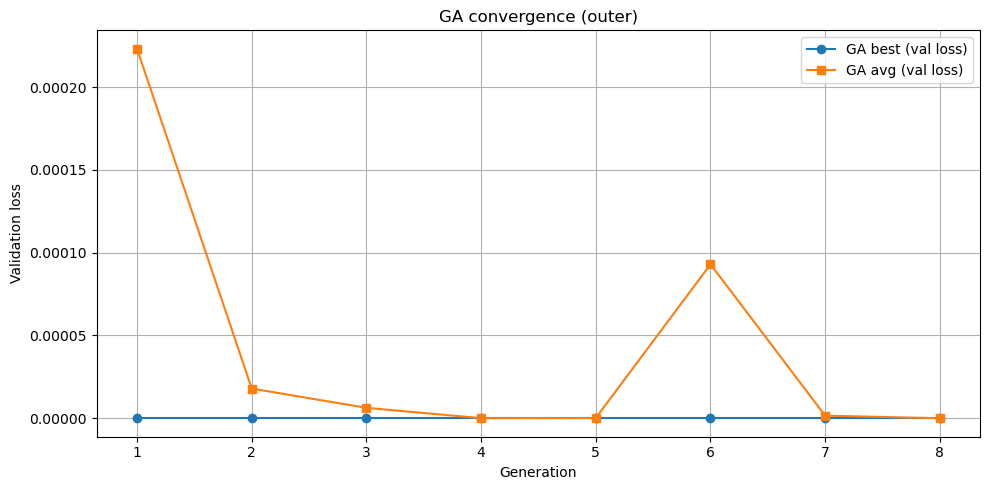

In [3]:
# PSO optimizes weights+biases. 
# GA optimizes hidden neurons, learning rate, momentum.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score
import time

np.random.seed(42)

INPUT_DIM = 4 # iris ke features
NUM_CLASSES = 3 # different classes

MIN_HIDDEN = 5 # kitne hidden layers ho sakte hai min
MAX_HIDDEN = 20 # max

# GA (outer) 
GA_POP = 8  # population (8 individuals)
GA_GENS = 8 # generation
GA_P_CROSS = 0.9 # crossover prob. (2 parents kitne time reproduce kr sakte hai)
GA_P_MUT = 0.2 # mutation hone he chances
GA_TOURN = 3 # best 3 individuals will be selected

# PSO (inner) - demo sizes
PSO_PARTICLES = 30 # population
PSO_ITERS = 120 # kitne iterations 

W_INERT = 0.7 # inertia weignt (Controls how much particle keeps its previous velocity.)
C1 = 1.5 # cognitive coeff (How strongly particle follows personal best.)
C2 = 1.5 # social coeff (How strongly particle follows global best.)

INIT_WEIGHTS_SCALE = 0.5 # Controls magnitude of randomly initialized weights.

FT_EPOCHS = 3
BATCH_SIZE = 16

TEST_SIZE = 0.2
VAL_SIZE = 0.2

LR_BOUNDS = (1e-4, 1.0) # learning rate 
MOM_BOUNDS = (0.0, 0.99) # momentum

def one_hot(y, n_classes):
    enc = OneHotEncoder(sparse_output=False, categories='auto')
    return enc.fit_transform(y.reshape(-1,1))

def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    e = np.exp(z)
    return e / np.sum(e, axis=1, keepdims=True)

def cross_entropy(preds, y_onehot):
    eps = 1e-12
    p = np.clip(preds, eps, 1 - eps)
    return -np.mean(np.sum(y_onehot * np.log(p), axis=1))

class MLP_Simple:
    def __init__(self, input_dim, hidden_dim, out_dim, params_flat=None):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.out_dim = out_dim
        if params_flat is None:
            self.W1 = np.random.randn(input_dim, hidden_dim) * 0.1
            self.b1 = np.zeros(hidden_dim)
            self.W2 = np.random.randn(hidden_dim, out_dim) * 0.1
            self.b2 = np.zeros(out_dim)
        else:
            self.set_params_from_flat(params_flat)

    def forward(self, X):
        Z1 = X.dot(self.W1) + self.b1
        A1 = np.tanh(Z1)
        Z2 = A1.dot(self.W2) + self.b2
        A2 = softmax(Z2)
        cache = {'X': X, 'Z1': Z1, 'A1': A1, 'Z2': Z2, 'A2': A2}
        return A2, cache

    def predict(self, X):
        probs, _ = self.forward(X)
        return np.argmax(probs, axis=1)

    def get_flat_param_count(self):
        return self.input_dim * self.hidden_dim + self.hidden_dim + self.hidden_dim * self.out_dim + self.out_dim

    def get_params_flat(self):
        return np.concatenate([self.W1.ravel(), self.b1.ravel(), self.W2.ravel(), self.b2.ravel()])

    def set_params_from_flat(self, flat_vec):
        idx = 0
        w1_size = self.input_dim * self.hidden_dim
        self.W1 = flat_vec[idx: idx + w1_size].reshape(self.input_dim, self.hidden_dim); idx += w1_size
        b1_size = self.hidden_dim
        self.b1 = flat_vec[idx: idx + b1_size].copy(); idx += b1_size
        w2_size = self.hidden_dim * self.out_dim
        self.W2 = flat_vec[idx: idx + w2_size].reshape(self.hidden_dim, self.out_dim); idx += w2_size
        b2_size = self.out_dim
        self.b2 = flat_vec[idx: idx + b2_size].copy(); idx += b2_size

    def sgd_step(self, X, y_oh, lr, momentum, velocity):
        probs, cache = self.forward(X)
        n = X.shape[0]
        dZ2 = (probs - y_oh) / n
        dW2 = cache['A1'].T.dot(dZ2)
        db2 = np.sum(dZ2, axis=0)
        dA1 = dZ2.dot(self.W2.T)
        dZ1 = dA1 * (1 - np.tanh(cache['Z1'])**2)
        dW1 = cache['X'].T.dot(dZ1)
        db1 = np.sum(dZ1, axis=0)

        grads = {'W1': dW1, 'b1': db1, 'W2': dW2, 'b2': db2}
        for k in ['W1','b1','W2','b2']:
            if k not in velocity:
                velocity[k] = np.zeros_like(grads[k])
            velocity[k] = momentum * velocity[k] - lr * grads[k]
            setattr(self, k, getattr(self, k) + velocity[k])
        return velocity

def pso_optimize_weights_for_arch(X_train, y_train_oh, X_val, y_val_oh, input_dim, hidden_dim, out_dim,
                                  lr, momentum, n_particles=PSO_PARTICLES, n_iters=PSO_ITERS):
    temp_model = MLP_Simple(input_dim, hidden_dim, out_dim)
    dim = temp_model.get_flat_param_count()
    pos = np.random.randn(n_particles, dim) * INIT_WEIGHTS_SCALE
    vel = np.random.randn(n_particles, dim) * (INIT_WEIGHTS_SCALE * 0.1)

    pbest_pos = pos.copy()
    pbest_score = np.full(n_particles, np.inf)
    gbest_pos = None
    gbest_score = np.inf
    history = []

    def eval_flat(flat_vec):
        model = MLP_Simple(input_dim, hidden_dim, out_dim, params_flat=flat_vec)
        velocity = {}
        n = X_train.shape[0]
        for ep in range(FT_EPOCHS):
            perm = np.random.permutation(n)
            for i in range(0, n, BATCH_SIZE):
                idx = perm[i:i+BATCH_SIZE]
                model.sgd_step(X_train[idx], y_train_oh[idx], lr=lr, momentum=momentum, velocity=velocity)
        probs, _ = model.forward(X_val)
        return cross_entropy(probs, y_val_oh)

    for it in range(n_iters):
        for i in range(n_particles):
            score = eval_flat(pos[i])
            if score < pbest_score[i]:
                pbest_score[i] = score
                pbest_pos[i] = pos[i].copy()
            if score < gbest_score:
                gbest_score = score
                gbest_pos = pos[i].copy()
        r1 = np.random.rand(n_particles, dim)
        r2 = np.random.rand(n_particles, dim)
        vel = W_INERT * vel + C1 * r1 * (pbest_pos - pos) + C2 * r2 * (gbest_pos - pos)
        pos = pos + vel
        history.append(gbest_score)
    return gbest_pos.copy(), gbest_score, history

def squash01(x):
    return 1.0 / (1.0 + np.exp(-x))

def decode_genes(genes):
    h_float, lr_gene, mom_gene = genes
    h_norm = squash01(h_float)
    hidden = int(round(MIN_HIDDEN + h_norm * (MAX_HIDDEN - MIN_HIDDEN)))
    hidden = max(MIN_HIDDEN, min(MAX_HIDDEN, hidden))
    lr = LR_BOUNDS[0] + squash01(lr_gene) * (LR_BOUNDS[1] - LR_BOUNDS[0])
    mom = MOM_BOUNDS[0] + squash01(mom_gene) * (MOM_BOUNDS[1] - MOM_BOUNDS[0])
    return hidden, lr, mom

def tournament_pop_select(pop, fitness, k=GA_TOURN):
    selected = np.random.choice(len(pop), size=k, replace=False)
    best = selected[0]
    for idx in selected:
        if fitness[idx] < fitness[best]:
            best = idx
    return best

def crossover(a, b):
    mask = np.random.rand(len(a)) < 0.5
    child = a.copy()
    child[mask] = b[mask]
    return child

def mutate(gene, p_mut=GA_P_MUT, sigma=0.5):
    out = gene.copy()
    for i in range(len(out)):
        if np.random.rand() < p_mut:
            out[i] += np.random.randn() * sigma
    return out

def ga_optimize(X_train, y_train_oh, X_val, y_val_oh):
    pop = [np.random.randn(3) for _ in range(GA_POP)]
    fitness = np.full(GA_POP, np.inf)
    evaluated = {}
    best_record = None
    gen_history = []

    for gen in range(GA_GENS):
        print(f"GA gen {gen+1}/{GA_GENS}")
        for i in range(GA_POP):
            genes = pop[i]
            key = tuple(np.round(genes, 6))
            if key in evaluated:
                fitness[i] = evaluated[key]['loss']
            else:
                hidden, lr, mom = decode_genes(genes)
                best_flat, best_loss, pso_hist = pso_optimize_weights_for_arch(
                    X_train, y_train_oh, X_val, y_val_oh,
                    INPUT_DIM, hidden, NUM_CLASSES,
                    lr=lr, momentum=mom,
                    n_particles=PSO_PARTICLES, n_iters=PSO_ITERS
                )
                fitness[i] = best_loss
                evaluated[key] = {'loss': best_loss, 'hidden': hidden, 'lr': lr, 'mom': mom, 'flat': best_flat, 'pso_history': pso_hist}
                print(f"  indiv {i}: hidden {hidden} lr {lr:.5f} mom {mom:.4f}  val_loss {best_loss:.4f}")
            if best_record is None or fitness[i] < best_record['loss']:
                h, lr_, m_ = decode_genes(pop[i])
                best_record = {'loss': fitness[i], 'genes': pop[i].copy(), 'hidden': h, 'lr': lr_, 'mom': m_, 'flat': evaluated[key]['flat']}
        gen_best = np.min(fitness)
        gen_avg = np.mean(fitness)
        gen_history.append({'gen': gen, 'best': gen_best, 'avg': gen_avg})
        print(f"  gen best {gen_best:.4f} avg {gen_avg:.4f} overall best {best_record['loss']:.4f}")
        # create next gen (elitism 1)
        new_pop = []
        best_idx = int(np.argmin(fitness))
        new_pop.append(pop[best_idx].copy())
        while len(new_pop) < GA_POP:
            a_idx = tournament_pop_select(pop, fitness)
            b_idx = tournament_pop_select(pop, fitness)
            a = pop[a_idx].copy()
            b = pop[b_idx].copy()
            child = crossover(a, b) if np.random.rand() < GA_P_CROSS else a
            child = mutate(child)
            new_pop.append(child)
        pop = new_pop
    return best_record, gen_history, evaluated

iris = load_iris()
X = iris.data
y = iris.target
scaler = StandardScaler()
X = scaler.fit_transform(X)
y_oh = one_hot(y, NUM_CLASSES)

X_train_full, X_test, y_train_full_oh, y_test_oh = train_test_split(X, y_oh, test_size=TEST_SIZE, random_state=42, stratify=y)
X_train, X_val, y_train_oh, y_val_oh = train_test_split(X_train_full, y_train_full_oh, test_size=VAL_SIZE, random_state=1, stratify=np.argmax(y_train_full_oh, axis=1))

print("Shapes: train", X_train.shape, "val", X_val.shape, "test", X_test.shape)

start = time.time()
best_record, gen_history, evaluated = ga_optimize(X_train, y_train_oh, X_val, y_val_oh)
print("GA+PSO done in %.1fs" % (time.time() - start))
print("Best:", best_record['hidden'], "lr", best_record['lr'], "mom", best_record['mom'], "val_loss", best_record['loss'])

# final model and eval
final_model = MLP_Simple(INPUT_DIM, best_record['hidden'], NUM_CLASSES)
final_model.set_params_from_flat(best_record['flat'])
# small fine tune
X_full = np.vstack([X_train, X_val])
y_full = np.vstack([y_train_oh, y_val_oh])
velocity = {}
for ep in range(30):
    perm = np.random.permutation(X_full.shape[0])
    for i in range(0, X_full.shape[0], BATCH_SIZE):
        idx = perm[i:i+BATCH_SIZE]
        final_model.sgd_step(X_full[idx], y_full[idx], lr=best_record['lr'], momentum=best_record['mom'], velocity=velocity)

probs, _ = final_model.forward(X_test)
test_loss = cross_entropy(probs, y_test_oh)
test_acc = accuracy_score(np.argmax(y_test_oh, axis=1), np.argmax(probs, axis=1))
print("Test loss: %.4f Test acc: %.4f" % (test_loss, test_acc))

# convergence plot
gens = [h['gen']+1 for h in gen_history]
best_vals = [h['best'] for h in gen_history]
avg_vals = [h['avg'] for h in gen_history]

plt.figure(figsize=(10,5))
plt.plot(gens, best_vals, marker='o', label='GA best (val loss)')
plt.plot(gens, avg_vals, marker='s', label='GA avg (val loss)')
plt.title('GA convergence (outer)')
plt.xlabel('Generation')
plt.ylabel('Validation loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Generation 1
ind 0 loss 0.008270302641348985
ind 1 loss 1.498259442502608e-06
ind 2 loss 0.0014307318372471743
ind 3 loss 0.0022234150614311786
ind 4 loss 0.02878252905753866
ind 5 loss 8.151700507243421e-05
ind 6 loss 3.4723734171332574e-06
ind 7 loss 0.0017274238265330827
Generation 2
ind 0 loss 9.999778782803785e-13
ind 1 loss 1.4264604196499516e-05
ind 2 loss 1.251720892167739e-06
ind 3 loss 2.387321821714871e-12
ind 4 loss 0.004914363823221669
ind 5 loss 5.005459010314784e-12
ind 6 loss 0.0014515860251239105
ind 7 loss 0.0009700427032719965
Generation 3
ind 0 loss 9.113297946374979e-08
ind 1 loss 9.999778782803785e-13
ind 2 loss 2.955383160542485e-11
ind 3 loss 9.999778782803785e-13
ind 4 loss 6.271657765704504e-09
ind 5 loss 6.237542432841022e-10
ind 6 loss 1.2038738526562423e-10
ind 7 loss 9.999778782803785e-13
Generation 4
ind 0 loss 3.081647900136623e-11
ind 1 loss 7.970822560122627e-09
ind 2 loss 1.1295276756954226e-10
ind 3 loss 6.300131588689119e-07
ind 4 loss 2.93835666319

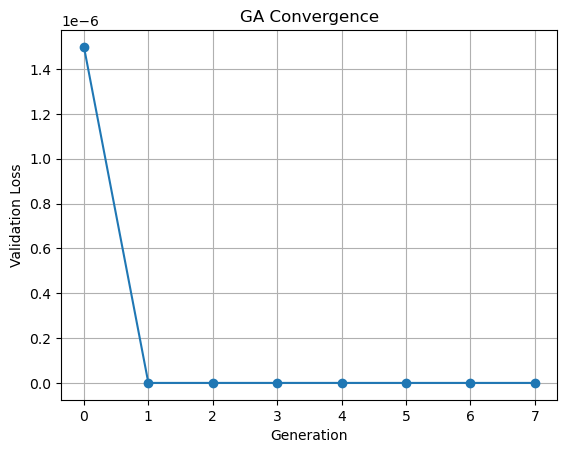

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score
import time

np.random.seed(42)

INPUT_DIM = 4 # iris ke features
NUM_CLASSES = 3 # different classes

MIN_HIDDEN = 5 # kitne hidden layers ho sakte hai min
MAX_HIDDEN = 20 # max

# GA (outer) 
GA_POP = 8  # population (8 individuals)
GA_GENS = 8 # generation
GA_P_CROSS = 0.9 # crossover prob. (2 parents kitne time reproduce kr sakte hai)
GA_P_MUT = 0.2 # mutation hone he chances
GA_TOURN = 3 # best 3 individuals will be selected

# PSO (inner) - demo sizes
PSO_PARTICLES = 30 # population
PSO_ITERS = 120 # kitne iterations 

W_INERT = 0.7 # inertia weignt (Controls how much particle keeps its previous velocity.)
C1 = 1.5 # cognitive coeff (How strongly particle follows personal best.)
C2 = 1.5 # social coeff (How strongly particle follows global best.)

INIT_WEIGHTS_SCALE = 0.5 # Controls magnitude of randomly initialized weights.

FT_EPOCHS = 3
BATCH_SIZE = 16

TEST_SIZE = 0.2
VAL_SIZE = 0.2

LR_BOUNDS = (1e-4, 1.0)
MOM_BOUNDS = (0.0, 0.99)


def one_hot(y):
    enc = OneHotEncoder(sparse_output=False)
    return enc.fit_transform(y.reshape(-1,1))


def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    e = np.exp(z)
    return e / np.sum(e, axis=1, keepdims=True)


def cross_entropy(preds, y_onehot):
    eps = 1e-12
    p = np.clip(preds, eps, 1 - eps)
    return -np.mean(np.sum(y_onehot * np.log(p), axis=1))


def squash01(x):
    return 1/(1+np.exp(-x))


class MLP_Simple:

    def __init__(self,input_dim,hidden_dim,out_dim,params_flat=None):

        self.input_dim=input_dim # 4 input 
        self.hidden_dim=hidden_dim # 10 hidden neuron 
        self.out_dim=out_dim # 3 classes

        if params_flat is None: # check if weights are initialize

            self.W1=np.random.randn(input_dim,hidden_dim)*0.1 # created 4x10 matrix and multiplication with 0.1 keeps weight small
            self.b1=np.zeros(hidden_dim) # bias for hidden neurons

            self.W2=np.random.randn(hidden_dim,out_dim)*0.1 # hidden->output layer weights
            self.b2=np.zeros(out_dim) # output bias

        else: # load optimized ones
            self.set_params_from_flat(params_flat) # pso works with flat vector but neural network works with matrix


    def forward(self,X):  # forward propagation

        Z1=X.dot(self.W1)+self.b1
        A1=np.tanh(Z1) # hidden layer activation function 

        Z2=A1.dot(self.W2)+self.b2
        A2=softmax(Z2) # output layer activation function

        cache={'X':X,'Z1':Z1,'A1':A1} # used for back prop

        return A2,cache


    def predict(self,X):
        p,_=self.forward(X)
        return np.argmax(p,axis=1)


    def get_flat_param_count(self): # return total number of params  because each particle is vector of params

        return (self.input_dim*self.hidden_dim
                +self.hidden_dim
                +self.hidden_dim*self.out_dim
                +self.out_dim)


    def get_params_flat(self): # converts all weights and bias into 1 vector

        return np.concatenate([

            self.W1.ravel(), # revel() converts matrix into vector 
            self.b1.ravel(),
            self.W2.ravel(),
            self.b2.ravel()

        ])


    def set_params_from_flat(self,flat): # vector se matrix

        idx=0

        w1=self.input_dim*self.hidden_dim
        self.W1=flat[idx:idx+w1].reshape(self.input_dim,self.hidden_dim)
        idx+=w1

        b1=self.hidden_dim
        self.b1=flat[idx:idx+b1]
        idx+=b1

        w2=self.hidden_dim*self.out_dim
        self.W2=flat[idx:idx+w2].reshape(self.hidden_dim,self.out_dim)
        idx+=w2

        b2=self.out_dim
        self.b2=flat[idx:idx+b2]


    def sgd_step(self,X,y,lr,momentum,velocity): # step grad descent for fine tuning

        probs,cache=self.forward(X)
        n=X.shape[0]

        dZ2=(probs-y)/n
        dW2=cache['A1'].T.dot(dZ2)
        db2=np.sum(dZ2,axis=0)

        dA1=dZ2.dot(self.W2.T)
        dZ1=dA1*(1-np.tanh(cache['Z1'])**2)

        dW1=cache['X'].T.dot(dZ1)
        db1=np.sum(dZ1,axis=0)

        grads={'W1':dW1,'b1':db1,'W2':dW2,'b2':db2}

        for k in grads:

            if k not in velocity:
                velocity[k]=np.zeros_like(grads[k])

            velocity[k]=momentum*velocity[k]-lr*grads[k]

            setattr(self,k,getattr(self,k)+velocity[k])

        return velocity


def pso_optimize_weights(Xtr,ytr,Xv,yv,input_dim,hidden_dim,out_dim,lr,momentum):

    temp=MLP_Simple(input_dim,hidden_dim,out_dim) # create temp neural network (only need to calc how many params exist)

    dim=temp.get_flat_param_count()

    pos=np.random.randn(PSO_PARTICLES,dim)*INIT_WEIGHTS_SCALE
    vel=np.random.randn(PSO_PARTICLES,dim)*0.1

    pbest=pos.copy()
    pbest_score=np.full(PSO_PARTICLES,np.inf)

    gbest=None
    gbest_score=np.inf


    def evaluate(flat): # fitness function

        model=MLP_Simple(input_dim,hidden_dim,out_dim,flat)

        velocity={}

        for ep in range(FT_EPOCHS):

            perm=np.random.permutation(Xtr.shape[0])

            for i in range(0,Xtr.shape[0],BATCH_SIZE):

                idx=perm[i:i+BATCH_SIZE]

                model.sgd_step(Xtr[idx],ytr[idx],lr,momentum,velocity)

        probs,_=model.forward(Xv)

        return cross_entropy(probs,yv)


    for it in range(PSO_ITERS):

        for i in range(PSO_PARTICLES):

            score=evaluate(pos[i])

            if score<pbest_score[i]:

                pbest_score[i]=score
                pbest[i]=pos[i]

            if score<gbest_score:

                gbest_score=score
                gbest=pos[i]

        r1=np.random.rand(PSO_PARTICLES,dim)
        r2=np.random.rand(PSO_PARTICLES,dim)

        vel=W_INERT*vel+C1*r1*(pbest-pos)+C2*r2*(gbest-pos)

        pos=pos+vel

    return gbest,gbest_score


def decode_features(genes): # decide which feature to use

    mask=squash01(genes)>0.5

    if np.sum(mask)==0:
        mask[np.argmax(genes)]=True

    return mask


def decode_genes(genes): # converts chromosome into model params
# chromosome = [h,lr,momentum,f1, f2,f3....]
    h,lr_g,m_g=genes[:3]
    feat_genes=genes[3:]

    hidden=int(round(MIN_HIDDEN+squash01(h)*(MAX_HIDDEN-MIN_HIDDEN))) # compute no of neuron in layer

    lr=LR_BOUNDS[0]+squash01(lr_g)*(LR_BOUNDS[1]-LR_BOUNDS[0])
    mom=MOM_BOUNDS[0]+squash01(m_g)*(MOM_BOUNDS[1]-MOM_BOUNDS[0])

    mask=decode_features(feat_genes) # feature selection

    return hidden,lr,mom,mask


def tournament(pop,fitness): # select parents for reproduction

    ids=np.random.choice(len(pop),GA_TOURN,replace=False) # select 3 random individuals

    best=ids[0] # assume 1st is best

    for i in ids: # find best among 3
        if fitness[i]<fitness[best]:
            best=i

    return best


def ga_optimize(Xtr,ytr,Xv,yv):

    gene_len=3+INPUT_DIM

    pop=[np.random.randn(gene_len) for _ in range(GA_POP)] # initialize gene

    fitness=np.full(GA_POP,np.inf) # initialize fitness to inf

    best=None
    history=[]

    for gen in range(GA_GENS):

        print("Generation",gen+1)

        for i in range(GA_POP):

            hidden,lr,mom,mask=decode_genes(pop[i])

            Xtr_m=Xtr[:,mask] # keep only selected features
            Xv_m=Xv[:,mask]

            flat,loss=pso_optimize_weights(

                Xtr_m,ytr,
                Xv_m,yv,
                Xtr_m.shape[1],
                hidden,
                NUM_CLASSES,
                lr,
                mom
            )

            fitness[i]=loss

            if best is None or loss<best['loss']:

                best={'loss':loss,'genes':pop[i],'hidden':hidden,
                      'lr':lr,'mom':mom,'mask':mask,'flat':flat}

            print("ind",i,"loss",loss)

        history.append(np.min(fitness))

        new=[pop[np.argmin(fitness)]] # best individual survives (elitism)

        while len(new)<GA_POP: # create new popu

            a=pop[tournament(pop,fitness)]
            b=pop[tournament(pop,fitness)]

            child=a.copy()

            if np.random.rand()<GA_P_CROSS: # crossover

                mask=np.random.rand(len(child))<0.5
                child[mask]=b[mask] 

            for g in range(len(child)): # mutation

                if np.random.rand()<GA_P_MUT:
                    child[g]+=np.random.randn()*0.5

            new.append(child)

        pop=new

    return best,history


iris=load_iris()

X=iris.data
y=iris.target

scaler=StandardScaler()
X=scaler.fit_transform(X)

y_oh=one_hot(y)

Xtr_full,Xtest,ytr_full,ytest=train_test_split(
    X,y_oh,test_size=TEST_SIZE,stratify=y,random_state=42)

Xtr,Xval,ytr,yval=train_test_split(
    Xtr_full,ytr_full,test_size=VAL_SIZE,
    stratify=np.argmax(ytr_full,1),random_state=1)


start=time.time()

best,history=ga_optimize(Xtr,ytr,Xval,yval)

print("Optimization time:",time.time()-start)

print("Best hidden:",best['hidden'])
print("Best lr:",best['lr'])
print("Best momentum:",best['mom'])
print("Selected features:",np.where(best['mask'])[0])

Xtr_m=Xtr[:,best['mask']]
Xval_m=Xval[:,best['mask']]
Xtest_m=Xtest[:,best['mask']]

model=MLP_Simple(Xtr_m.shape[1],best['hidden'],NUM_CLASSES)
model.set_params_from_flat(best['flat'])

Xfull=np.vstack([Xtr_m,Xval_m])
yfull=np.vstack([ytr,yval])

velocity={}

for ep in range(30):

    perm=np.random.permutation(Xfull.shape[0])

    for i in range(0,Xfull.shape[0],BATCH_SIZE):

        idx=perm[i:i+BATCH_SIZE]

        model.sgd_step(Xfull[idx],yfull[idx],
                       best['lr'],best['mom'],velocity)


probs,_=model.forward(Xtest_m)

test_loss=cross_entropy(probs,ytest)

test_acc=accuracy_score(
    np.argmax(ytest,1),
    np.argmax(probs,1)
)

print("Test loss:",test_loss)
print("Test accuracy:",test_acc)


plt.plot(history,marker='o')
plt.xlabel("Generation")
plt.ylabel("Validation Loss")
plt.title("GA Convergence")
plt.grid(True)
plt.show()